# Nifty 200 - 15 Min Data Exploration

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = '../../../nifty200_15min.db'
conn = sqlite3.connect(DB_PATH)
print('Connected to database')

Connected to database


In [2]:
# List all tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
print(f'Total tables: {len(tables)}')
tables

Total tables: 1


,name
0,candles


In [3]:
# Inspect schema of first table
first_table = tables['name'].iloc[0]
schema = pd.read_sql(f"PRAGMA table_info('{first_table}')", conn)
print(f'Schema for: {first_table}')
schema

Schema for: candles


,cid,name,type,notnull,dflt_value,pk
0,0,symbol,TEXT,1,None,1
1,1,datetime,TEXT,1,None,2
2,2,open,REAL,1,None,0
3,3,high,REAL,1,None,0
4,4,low,REAL,1,None,0
5,5,close,REAL,1,None,0
6,6,volume,INTEGER,1,None,0


In [4]:
# Load sample data from first table
df = pd.read_sql(f"SELECT * FROM '{first_table}' LIMIT 1000", conn)
print(f'Shape: {df.shape}')
df.head()

Shape: (1000, 7)


,symbol,datetime,open,high,low,close,volume
0,360ONE,2019-09-19 09:30:00,1210.00,1210.00,1210.00,1210.00,77848
1,360ONE,2022-09-08 09:15:00,431.89,456.25,431.69,434.63,14480
2,360ONE,2022-09-08 09:30:00,434.63,435.00,434.63,435.00,5840
3,360ONE,2022-09-08 09:45:00,435.00,437.50,435.00,437.50,10012
4,360ONE,2022-09-08 10:00:00,437.50,437.50,433.79,436.24,11856


In [7]:
# Load ASHOKLEY data
ashokley = pd.read_sql("SELECT * FROM candles WHERE symbol = 'ASHOKLEY' ORDER BY datetime", conn)
print(f'Shape: {ashokley.shape}')
ashokley.head()

Shape: (58938, 7)


,symbol,datetime,open,high,low,close,volume
0,ASHOKLEY,2016-10-03 09:15:00,39.58,40.58,39.55,40.08,5286110
1,ASHOKLEY,2016-10-03 09:30:00,40.08,40.45,40.05,40.38,1508136
2,ASHOKLEY,2016-10-03 09:45:00,40.38,40.70,40.33,40.55,1445884
3,ASHOKLEY,2016-10-03 10:00:00,40.58,40.60,40.45,40.50,735112
4,ASHOKLEY,2016-10-03 10:15:00,40.50,40.60,40.50,40.55,531502


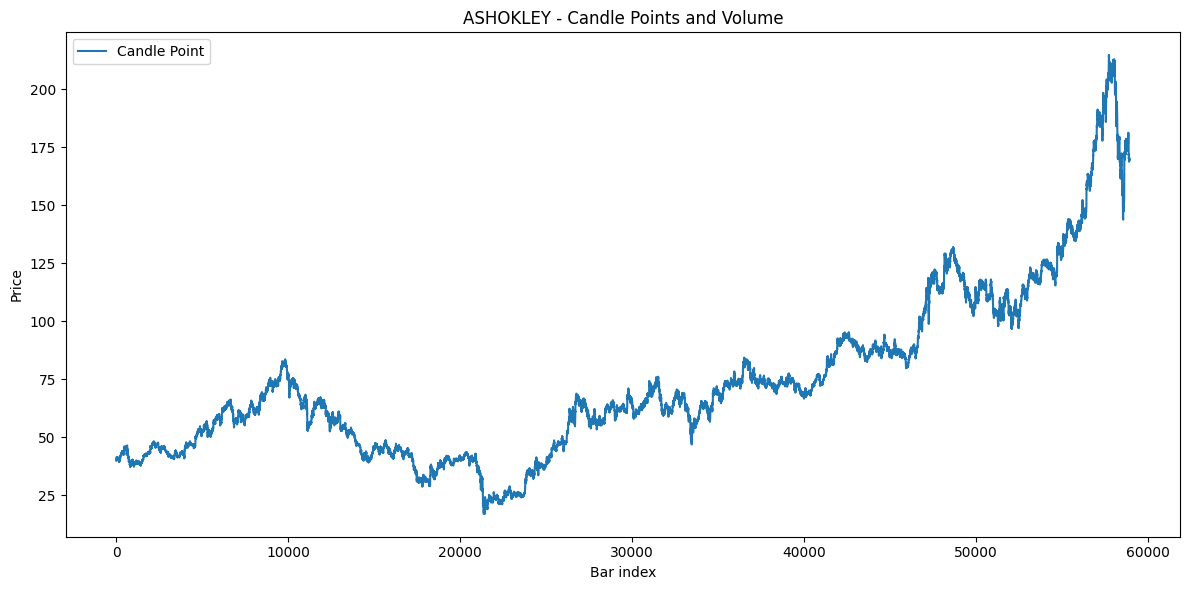

In [13]:

# convert ohlv to single point per candle
ashokley['candle_point'] = (ashokley['open'] + ashokley['high'] + ashokley['low'] + ashokley['close']) / 4
# Plot the candle points and volume too as a line chart
plt.figure(figsize=(12, 6))
plt.plot(ashokley['candle_point'].values, label='Candle Point')
# plt.plot(ashokley['volume'].values, label='Volume', color='orange')
plt.title('ASHOKLEY - Candle Points and Volume')
plt.xlabel('Bar index')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
conn.close()
print('Connection closed')